# Face Recognition: RetinaFace → Align → ArcFace

This notebook demonstrates face recognition **without** the high-level `FaceAnalyzer` wrapper. Each step is handled manually:

1. **RetinaFace**: Detects faces and extracts 5-point landmarks.
2. **Face Alignment**: Warps each face into a standardized 112x112 crop using the landmarks.
3. **ArcFace**: Generates a 512-D L2-normalized embedding from the aligned crop.

We compare three test images: `image0.jpg`, `image1.jpg`, and `image5.jpg`.

## 1. Install UniFace

In [1]:
%pip install -q uniface

# Clone repo for assets (Colab only)
import os
if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
    if not os.path.exists('uniface'):
        !git clone --depth 1 https://github.com/yakhyo/uniface.git
    os.chdir('uniface/examples')

Note: you may need to restart the kernel to use updated packages.


## 2. Import Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import uniface
from uniface.detection import RetinaFace
from uniface.recognition import ArcFace
from uniface.face_utils import face_alignment

print(f"UniFace version: {uniface.__version__}")

UniFace version: 3.3.0


## 3. Configuration

In [3]:
IMAGE_PATHS = {
    "image0": "../assets/test_images/image0.jpg",
    "image1": "../assets/test_images/image1.jpg",
    "image5": "../assets/test_images/image5.jpg",
}
THRESHOLD = 0.4   # Cosine similarity threshold for "same person"

## 4. Initialize Models

In [4]:
detector = RetinaFace(confidence_threshold=0.5)
recognizer = ArcFace()

## 5. Load Images & Detect Faces

We use the detector to find faces and their landmarks in each image.

In [5]:
images = {}
faces = {}

for name, path in IMAGE_PATHS.items():
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {path}")

    detected = detector.detect(img)
    if not detected:
        raise RuntimeError(f"No face detected in: {path}")

    images[name] = img
    faces[name] = detected[0]   # Keep highest-confidence face
    print(f"{name:8s} | {len(detected)} face(s) detected | confidence={faces[name].confidence:.3f}")

image0   | 1 face(s) detected | confidence=1.000
image1   | 1 face(s) detected | confidence=1.000
image5   | 1 face(s) detected | confidence=1.000


## 6. Visualize Detections

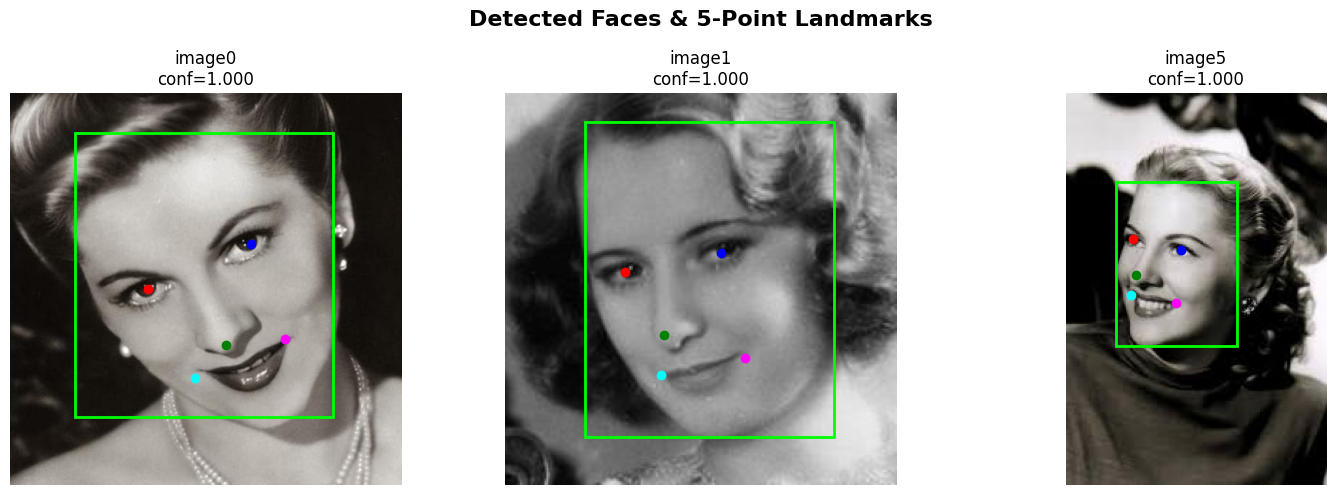

In [6]:
LM_COLORS = ["red", "blue", "green", "cyan", "magenta"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Detected Faces & 5-Point Landmarks", fontweight="bold", fontsize=16)

for ax, (name, img) in zip(axes, images.items()):
    face = faces[name]
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name}\nconf={face.confidence:.3f}", fontsize=12)
    ax.axis("off")

    # Bounding box
    x1, y1, x2, y2 = face.bbox.astype(int)
    ax.add_patch(patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor="lime", facecolor="none"))

    # Landmarks
    for (lx, ly), c in zip(face.landmarks, LM_COLORS):
        ax.plot(lx, ly, "o", color=c, markersize=6)

plt.tight_layout()
plt.show()

## 7. Face Alignment

We warp the detected faces into a standardized 112x112 size. This improves recognition accuracy.

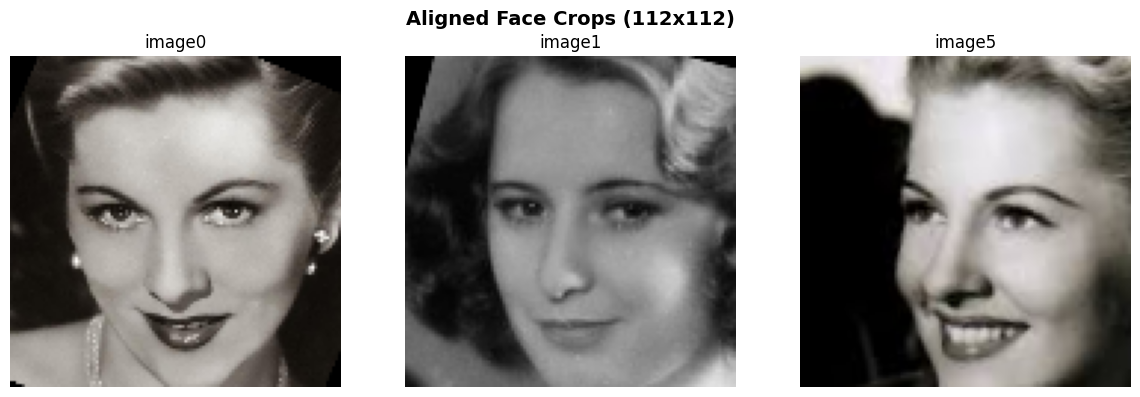

In [7]:
aligned = {}

for name, img in images.items():
    lm = faces[name].landmarks
    crop, _ = face_alignment(img, lm, image_size=(112, 112))
    aligned[name] = crop

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Aligned Face Crops (112x112)", fontweight="bold", fontsize=14)

for ax, (name, crop) in zip(axes, aligned.items()):
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Extract Embeddings

We pass the aligned crops to ArcFace to get the 512-D vectors.

In [8]:
embeddings = {}

for name, crop in aligned.items():
    # landmarks=None because image is already aligned
    emb = recognizer.get_normalized_embedding(crop, landmarks=None)
    embeddings[name] = emb
    print(f"{name:8s} | embedding shape={emb.shape} | L2-norm={np.linalg.norm(emb):.4f}")

image0   | embedding shape=(512,) | L2-norm=1.0000
image1   | embedding shape=(512,) | L2-norm=1.0000
image5   | embedding shape=(512,) | L2-norm=1.0000


## 9. Pairwise Cosine Similarity

Since embeddings are normalized, cosine similarity is just the dot product.

In [9]:
names = list(embeddings.keys())
n = len(names)
sim_matrix = np.zeros((n, n))

for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        # Use squeeze() to handle (1, 512) shapes if present
        sim_matrix[i, j] = float(np.dot(embeddings[ni].squeeze(), embeddings[nj].squeeze()))

# Print comparison results
pairs = [(names[i], names[j]) for i in range(n) for j in range(i + 1, n)]
for a, b in pairs:
    s = float(np.dot(embeddings[a].squeeze(), embeddings[b].squeeze()))
    verdict = "✓ Same person" if s >= THRESHOLD else "✗ Different people"
    print(f"{a} vs {b}: similarity={s:.4f} → {verdict}")

image0 vs image1: similarity=0.1135 → ✗ Different people
image0 vs image5: similarity=0.5450 → ✓ Same person
image1 vs image5: similarity=0.0723 → ✗ Different people


## 10. Similarity Heatmap

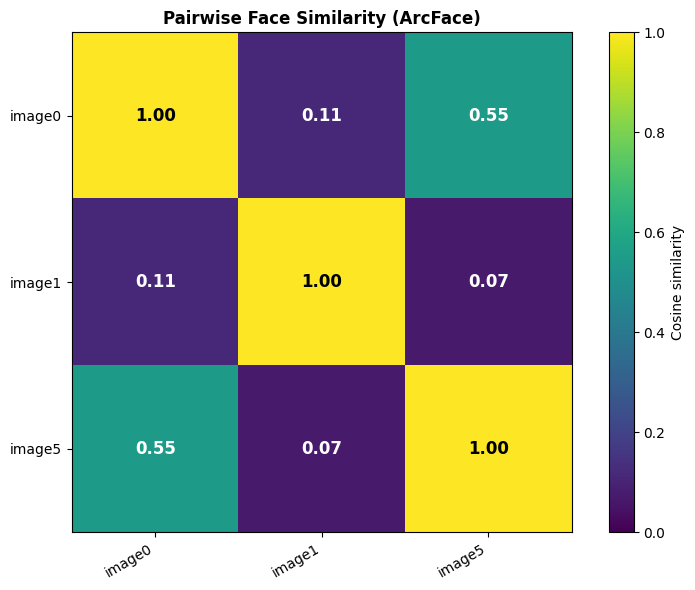

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap="viridis")
plt.colorbar(im, ax=ax, label="Cosine similarity")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_yticklabels(names)
ax.set_title("Pairwise Face Similarity (ArcFace)", fontweight="bold")

for i in range(n):
    for j in range(n):
        val = sim_matrix[i, j]
        ax.text(j, i, f"{val:.2f}",
                ha="center", va="center",
                color="black" if val >= 0.6 else "white",
                fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()